# Traveler Segmentation Analysis (NYC vs Dubai)

**Business Question:** *"What traveler archetypes exist in NYC→Dubai demand, and how should OTA pricing/merchandising differ by segment?"*

| # | Source | Signal | Used For |
|---|--------|--------|----------|
| 1 | Processed hotel dataset | market, price/rating/bookability context | traveler profile generation |
| 2 | Segmentation engine | feature engineering + KMeans/PCA + validation | actionable archetypes |

### Why This Matters
Different traveler groups behave differently:
- business vs leisure booking windows
- luxury vs budget willingness to pay
- family vs solo trip structures
- Dubai preference varies by segment

### Pipeline
1. Load processed hotels data
2. Generate synthetic traveler profiles
3. Engineer curated clustering features
4. Find optimal K (Inertia + Silhouette + CH)
5. Run KMeans and label clusters
6. Validate clusters statistically
7. Create segment-level OTA recommendations

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from config.settings import DATA_PROCESSED, FIGURES_DIR
from src.preprocessing.hotels import prepare_funnel_data
import src.analysis.traveler_segmentation as seg

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 120

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(DATA_PROCESSED / "traveler_segmentation").mkdir(parents=True, exist_ok=True)

print("✅ Setup complete")

✅ Setup complete


In [4]:
candidates = [
    DATA_PROCESSED / "booking_funnel" / "hotels_enriched_processed.csv",
    DATA_PROCESSED / "booking_funnel" / "hotels_enriched.csv",
    DATA_PROCESSED / "hotels_prepared.parquet",
    DATA_PROCESSED / "hotels_prepared.csv",
    DATA_PROCESSED / "hotels.csv",
]

hotels = None
source_used = None

for p in candidates:
    if p.exists():
        try:
            hotels = pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p)
            source_used = str(p)
            break
        except Exception as e:
            print(f"Failed reading {p.name}: {e}")

if hotels is None:
    raise FileNotFoundError(
        "No processed hotel dataset found for M04.\nChecked:\n" + "\n".join(str(x) for x in candidates)
    )

# Ensure required enriched fields exist
required_enriched = {"PRICE_TIER", "RATING_TIER", "VISIBILITY_SCORE", "IS_BOOKABLE"}
if not required_enriched.issubset(hotels.columns):
    hotels = prepare_funnel_data(hotels)

print(f"✅ Loaded hotels from: {source_used}")
print(f"Rows: {len(hotels):,}")
if "MARKET" in hotels.columns:
    print("Market distribution:", hotels["MARKET"].value_counts(dropna=False).to_dict())
display(hotels.head())

✅ Loaded hotels from: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel\hotels_enriched_processed.csv
Rows: 202
Market distribution: {'NYC': 106, 'Dubai': 96}


,PLACE_ID,NAME,MARKET,RATING,TOTAL_RATINGS,PRICE_LEVEL,ADDRESS,LAT,LNG,BUSINESS_STATUS,...,PHONE,NUM_PHOTOS,NUM_REVIEWS_FETCHED,AVG_REVIEW_RATING,REVIEW_TEXTS,OPEN_NOW,PRICE_TIER,RATING_TIER,VISIBILITY_SCORE,IS_BOOKABLE
0,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,4.7,30807,NaN,Dubai - Umm Suqeim Third - Umm Suqeim 3 - Duba...,25.141191,55.185247,OPERATIONAL,...,04 301 7777,10,5,5.0,Staying in a suite at the Burj Al Arab was tru...,NaN,Unknown,Excellent,92.8,True
1,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,4.7,101541,NaN,Crescent Rd - The Palm Jumeirah - Dubai - Unit...,25.130443,55.117150,OPERATIONAL,...,04 426 0000,10,5,4.8,🌟🌟🌟🌟🌟\nAtlantis The Palm meets the King of Lov...,NaN,Unknown,Excellent,97.9,True
2,ChIJ_-wTYzdrXz4RrrhErFCw21o,FIVE Palm Jumeirah Hotel,Dubai,4.7,25103,NaN,No. 1 Palm - The Palm Jumeirah - Dubai - Unite...,25.104330,55.148769,OPERATIONAL,...,04 455 9999,10,5,5.0,I had an amazing stay at **FIVE Palm Jumeirah*...,True,Unknown,Excellent,84.4,True
3,ChIJ9c0WNcoUXz4RmIIVjEG9uqo,One&Only The Palm,Dubai,4.7,3103,NaN,"West Crescent, Palm - نخلة جميرا - Jumeirah - ...",25.099485,55.133463,OPERATIONAL,...,04 440 1010,10,5,5.0,One&Only The Palm is the definition of quiet l...,True,Unknown,Excellent,52.4,True
4,ChIJ8-LpJSNCXz4RSYU8D8qlVl4,Bvlgari Resort Dubai,Dubai,4.6,3870,NaN,Jumeirah Bay Island - جميرا باي - جميرا ٢ - دب...,25.210697,55.236428,OPERATIONAL,...,04 777 5555,10,5,5.0,I had an amazing stay here. everything from th...,NaN,Unknown,Excellent,52.8,True


## Generate Traveler Profiles + Engineer Clustering Features

In [5]:
travelers = seg.generate_traveler_profiles(hotels, n_travelers=2000)
travelers_fe, cluster_features = seg.engineer_clustering_features(travelers)

print(f"Travelers generated: {len(travelers_fe):,}")
print(f"Feature count: {len(cluster_features)}")
print("Features:", cluster_features)
display(travelers_fe.head())

Generated 2,000 traveler profiles
  Purposes: {'leisure': np.int64(806), 'business': np.int64(599), 'honeymoon': np.int64(246), 'family_vacation': np.int64(197), 'transit': np.int64(152)}
Engineered 9 curated clustering features
Travelers generated: 2,000
Feature count: 9
Features: ['AGE', 'GROUP_SIZE', 'STAY_NIGHTS', 'LEAD_TIME_BUCKET', 'SPEND_PER_NIGHT_PP', 'HOTEL_FLIGHT_RATIO', 'PRICE_TIER_NUM', 'IS_LOYALTY', 'IS_DUBAI_PREF']


,TRAVELER_ID,AGE,GROUP_SIZE,NATIONALITY_REGION,TRIP_PURPOSE,STAY_NIGHTS,LEAD_TIME_DAYS,FARE_CLASS,FLIGHT_SPEND,PREFERRED_PRICE_TIER,...,REPEAT_VISITOR,HOTEL_FLIGHT_RATIO,SPEND_PER_NIGHT_PP,TOTAL_SPEND_PP,LEAD_TIME_BUCKET,IS_LOYALTY,IS_REPEAT,IS_MOBILE,IS_DUBAI_PREF,PRICE_TIER_NUM
0,T00000,26,2,International,leisure,12,57,economy,677.25,Mid-Range,...,False,4.758,134.25,1949.64,4.0,0,0,1,1,2
1,T00001,36,4,US_Other,family_vacation,6,14,economy,552.27,Budget,...,False,0.900,20.71,262.33,2.0,1,0,0,0,1
2,T00002,29,1,US_Northeast,transit,2,3,economy,483.44,Budget,...,False,0.331,80.00,643.44,1.0,0,0,0,0,1
3,T00003,25,1,US_Northeast,business,5,16,business,4166.92,Luxury,...,True,1.432,1193.75,10135.66,2.0,0,1,0,1,4
4,T00004,26,2,US_Northeast,leisure,10,52,economy,730.00,Budget,...,False,1.359,49.60,860.92,4.0,0,0,1,0,1


## K Selection — Inertia, Silhouette, Calinski-Harabasz

In [6]:
k_eval = seg.find_optimal_k(
    df=travelers_fe,
    features=cluster_features,
    k_range=range(2, 9),
    use_pca=True,
    pca_variance=0.90,
)

display(k_eval)

  PCA: 9 features -> 7 components (94.6% variance retained)


  File "c:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\dheer\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\dheer\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                  

  k=2: inertia=13225, silhouette=0.208, CH=575
  k=3: inertia=11726, silhouette=0.180, CH=452
  k=4: inertia=10397, silhouette=0.173, CH=425
  k=5: inertia=9662, silhouette=0.177, CH=381
  k=6: inertia=9096, silhouette=0.164, CH=348
  k=7: inertia=8572, silhouette=0.171, CH=328
  k=8: inertia=8129, silhouette=0.169, CH=312


,K,INERTIA,SILHOUETTE,CALINSKI_HARABASZ
0,2,13225.3,0.2077,575.5
1,3,11725.7,0.1802,452.1
2,4,10396.7,0.1729,424.8
3,5,9661.9,0.1772,380.6
4,6,9096.4,0.1643,348.0
5,7,8572.1,0.1714,327.9
6,8,8129.3,0.1690,311.7


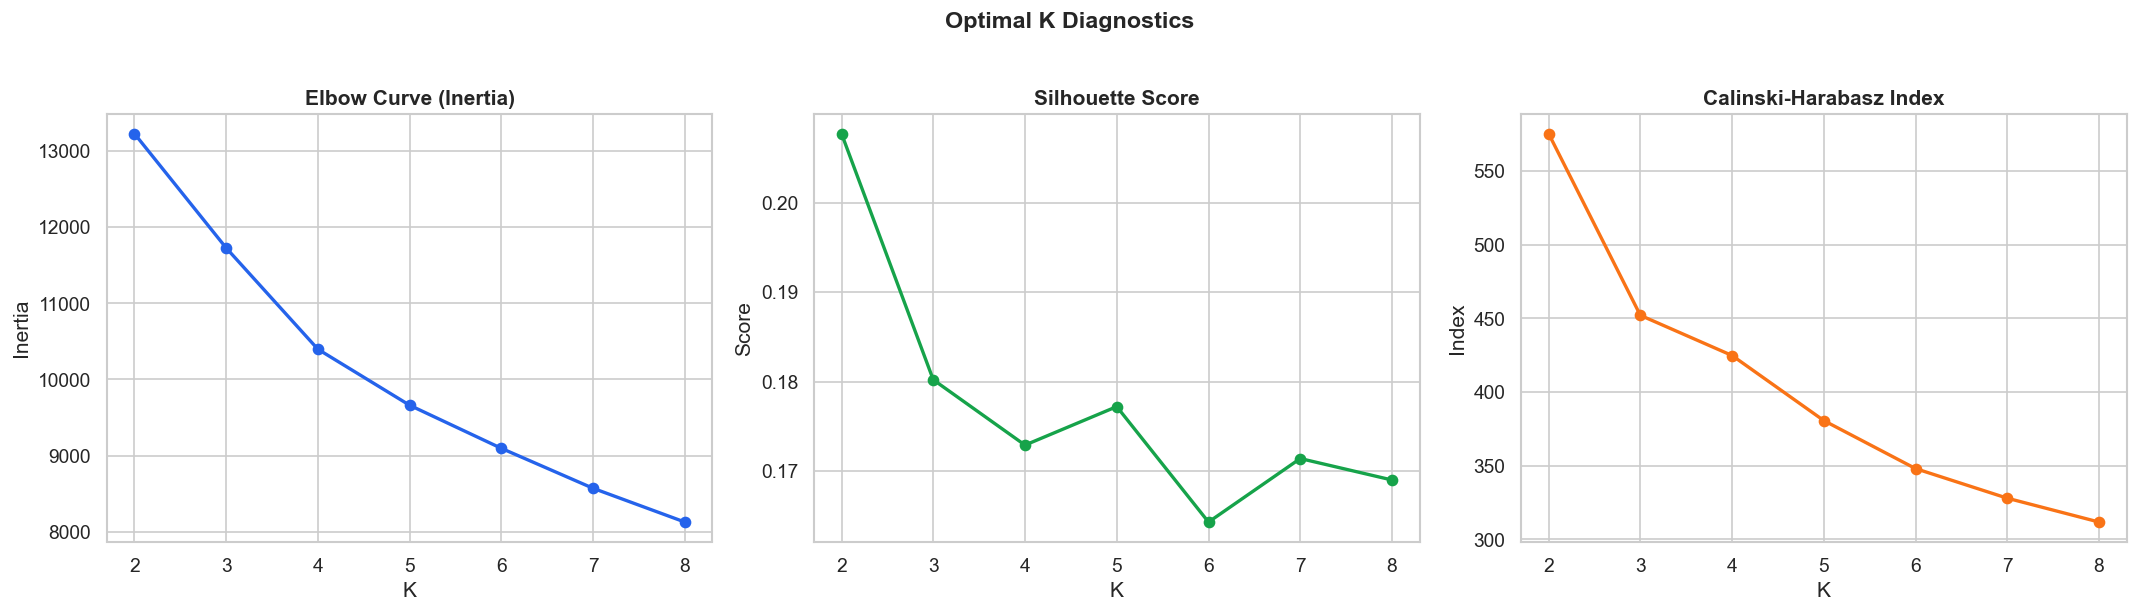

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_eval["K"], k_eval["INERTIA"], marker="o", linewidth=2, color="#2563eb")
axes[0].set_title("Elbow Curve (Inertia)", fontweight="bold")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_eval["K"], k_eval["SILHOUETTE"], marker="o", linewidth=2, color="#16a34a")
axes[1].set_title("Silhouette Score", fontweight="bold")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")

axes[2].plot(k_eval["K"], k_eval["CALINSKI_HARABASZ"], marker="o", linewidth=2, color="#f97316")
axes[2].set_title("Calinski-Harabasz Index", fontweight="bold")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Index")

plt.suptitle("Optimal K Diagnostics", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m04_k_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
k_best = int(k_eval.loc[k_eval["SILHOUETTE"].idxmax(), "K"])
print(f"✅ Selected K (best silhouette): {k_best}")

✅ Selected K (best silhouette): 2


## Run KMeans + Visualize PCA Clusters

In [9]:
clustered, km_model, scaler = seg.run_kmeans(
    df=travelers_fe,
    features=cluster_features,
    k=k_best,
    use_pca=True,
    pca_variance=0.90,
)

display(clustered.head())
print("Cluster sizes:", clustered["CLUSTER"].value_counts().sort_index().to_dict())

  PCA: 9 -> 7 components

K-Means (k=2): silhouette=0.208, CH=575
  Cluster sizes: {0: np.int64(1128), 1: np.int64(872)}


,TRAVELER_ID,AGE,GROUP_SIZE,NATIONALITY_REGION,TRIP_PURPOSE,STAY_NIGHTS,LEAD_TIME_DAYS,FARE_CLASS,FLIGHT_SPEND,PREFERRED_PRICE_TIER,...,TOTAL_SPEND_PP,LEAD_TIME_BUCKET,IS_LOYALTY,IS_REPEAT,IS_MOBILE,IS_DUBAI_PREF,PRICE_TIER_NUM,CLUSTER,PCA_1,PCA_2
0,T00000,26,2,International,leisure,12,57,economy,677.25,Mid-Range,...,1949.64,4.0,0,0,1,1,2,0,2.043522,0.535518
1,T00001,36,4,US_Other,family_vacation,6,14,economy,552.27,Budget,...,262.33,2.0,1,0,0,0,1,0,0.957576,-2.043766
2,T00002,29,1,US_Northeast,transit,2,3,economy,483.44,Budget,...,643.44,1.0,0,0,0,0,1,1,-0.704556,-2.622978
3,T00003,25,1,US_Northeast,business,5,16,business,4166.92,Luxury,...,10135.66,2.0,0,1,0,1,4,1,-2.694438,2.189999
4,T00004,26,2,US_Northeast,leisure,10,52,economy,730.00,Budget,...,860.92,4.0,0,0,1,0,1,0,1.854509,-1.373350


Cluster sizes: {0: 1128, 1: 872}


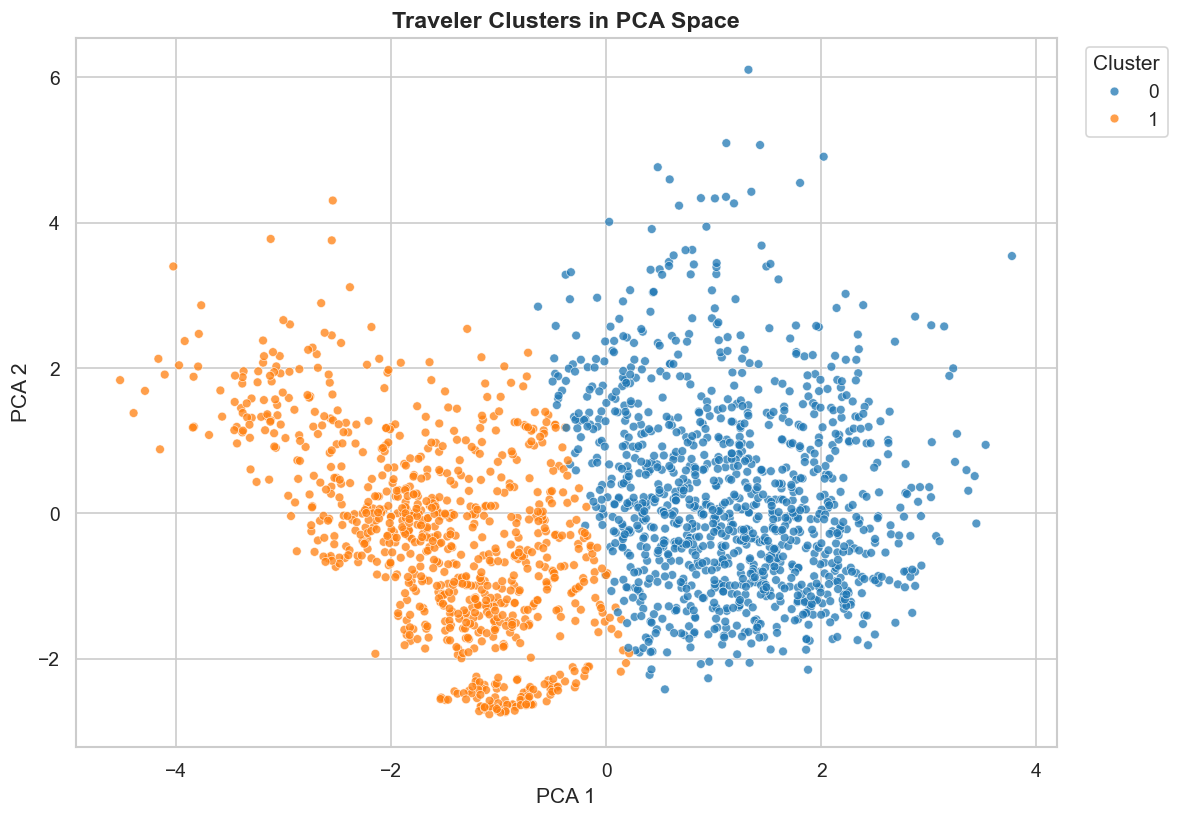

In [10]:
# PCA scatter plot
if {"PCA_1", "PCA_2", "CLUSTER"}.issubset(clustered.columns):
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(
        data=clustered,
        x="PCA_1",
        y="PCA_2",
        hue="CLUSTER",
        palette="tab10",
        s=28,
        alpha=0.75,
        ax=ax
    )
    ax.set_title("Traveler Clusters in PCA Space", fontsize=14, fontweight="bold")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "m04_pca_clusters.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("PCA columns not available; plot skipped.")

## Cluster Profiling + Archetype Labels

In [11]:
profiles = seg.profile_clusters(clustered)
profiles = seg.label_clusters(profiles)

display(
    profiles[
        [
            "CLUSTER", "ARCHETYPE", "SIZE", "PCT_OF_TOTAL",
            "AVG_AGE", "AVG_GROUP_SIZE", "AVG_STAY_NIGHTS", "AVG_LEAD_TIME",
            "AVG_TOTAL_SPEND", "TOP_PURPOSE", "TOP_PRICE_TIER",
            "PCT_DUBAI_PREF", "PCT_LOYALTY", "PCT_REPEAT"
        ]
    ].sort_values("SIZE", ascending=False)
)


Cluster Archetypes:
  Cluster 0: Comfort Leisure (n=1128, avg_spend=$3,927)
  Cluster 1: Corporate Traveler (n=872, avg_spend=$4,451)


,CLUSTER,ARCHETYPE,SIZE,PCT_OF_TOTAL,AVG_AGE,AVG_GROUP_SIZE,AVG_STAY_NIGHTS,AVG_LEAD_TIME,AVG_TOTAL_SPEND,TOP_PURPOSE,TOP_PRICE_TIER,PCT_DUBAI_PREF,PCT_LOYALTY,PCT_REPEAT
0,0,Comfort Leisure,1128,56.4,34.1,2.4,9.3,49.9,3927.0,leisure,Mid-Range,64.5,23.3,16.0
1,1,Corporate Traveler,872,43.6,37.7,1.2,3.6,13.3,4451.0,business,Upscale,50.8,49.7,16.7


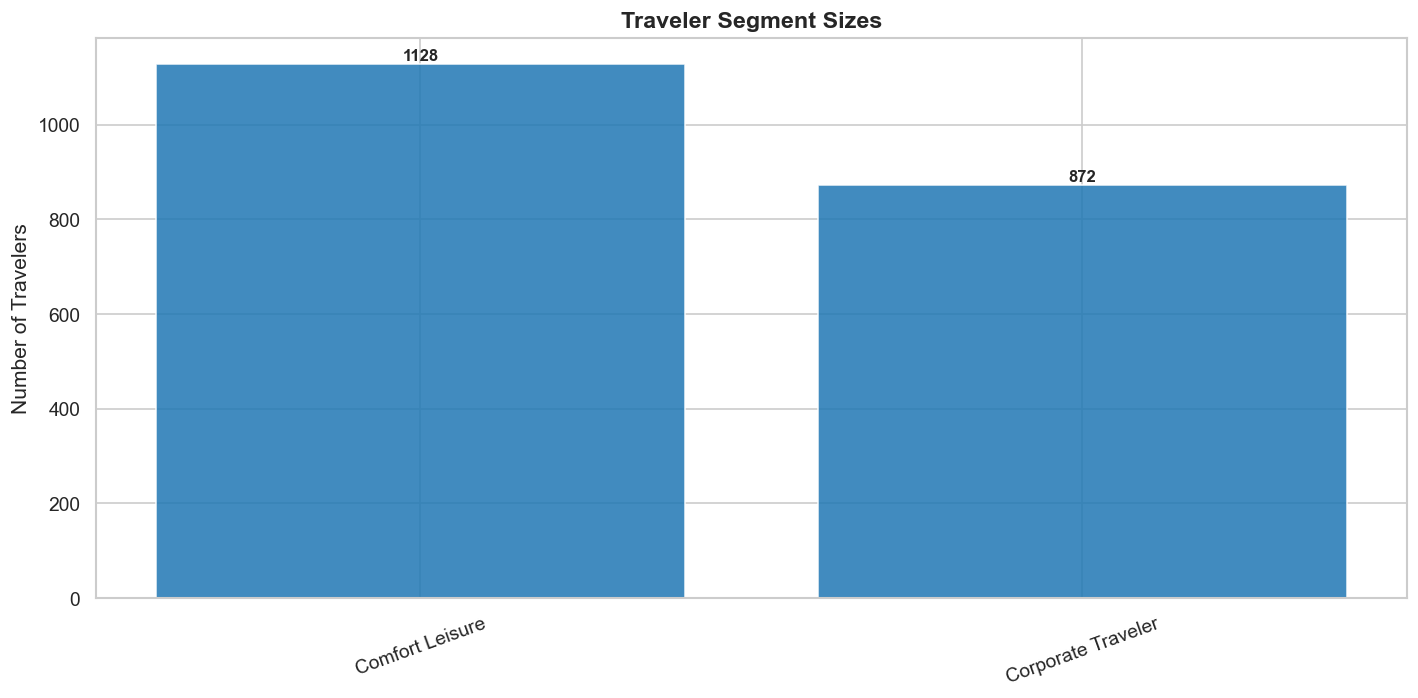

In [12]:
plot_profiles = profiles.sort_values("SIZE", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(plot_profiles["ARCHETYPE"], plot_profiles["SIZE"], color="#1f77b4", alpha=0.85, edgecolor="white")
ax.set_title("Traveler Segment Sizes", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Travelers")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)

for b, v in zip(bars, plot_profiles["SIZE"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 8, f"{int(v)}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "m04_segment_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

## Statistical Validation + Segment x Market

In [13]:
validation = seg.validate_segments(clustered)
display(validation)

sig_count = int(validation["SIGNIFICANT"].sum())
print(f"Significant metrics: {sig_count}/{len(validation)}")


Segment validation: 6/7 metrics show significant inter-cluster differences


,METRIC,H_STATISTIC,P_VALUE,SIGNIFICANT
0,TOTAL_TRIP_SPEND,1.03,0.311077,False
1,STAY_NIGHTS,1330.63,0.000000,True
2,LEAD_TIME_DAYS,718.44,0.000000,True
3,FLIGHT_SPEND,264.47,0.000000,True
4,HOTEL_SPEND_PER_NIGHT,92.87,0.000000,True
5,GROUP_SIZE,833.57,0.000000,True
6,AGE,93.65,0.000000,True


Significant metrics: 6/7


In [14]:
market_ct = seg.segment_market_crosstab(clustered, profiles)
display(market_ct)

,PCT_DUBAI,PCT_NYC
ARCHETYPE,,
Comfort Leisure,64.5,35.5
Corporate Traveler,50.8,49.2
All,58.5,41.5


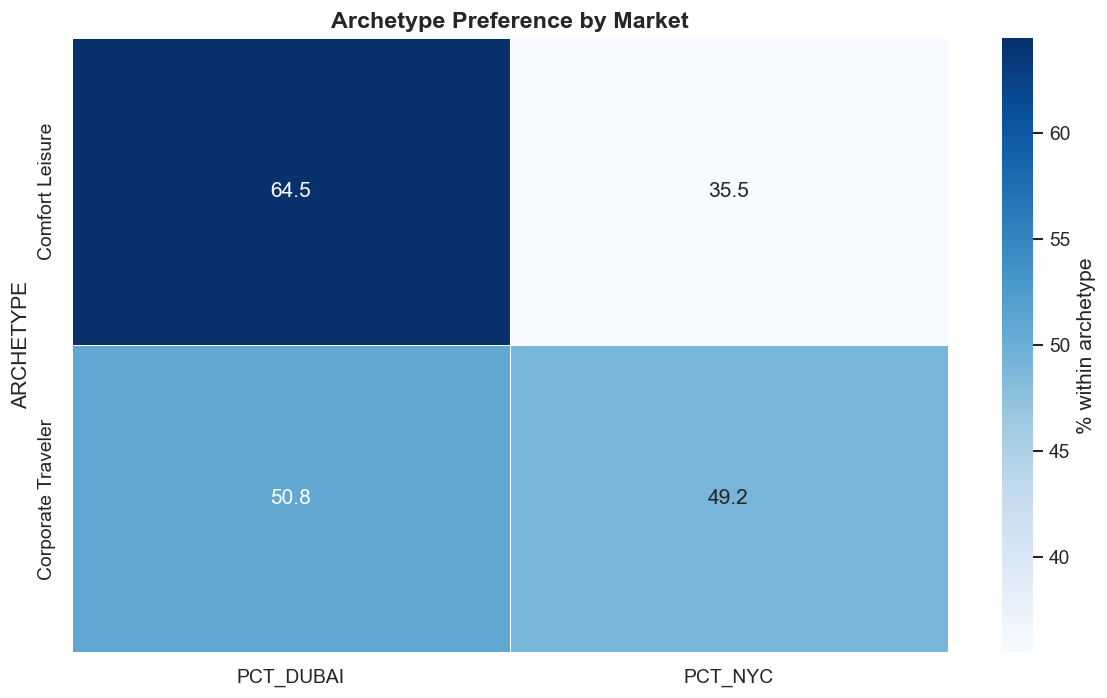

In [15]:
ct_plot = market_ct.drop(index="All", errors="ignore").copy()
ct_cols = [c for c in ct_plot.columns if c.startswith("PCT_") and c != "TOTAL_PCT"]

if len(ct_cols):
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(
        ct_plot[ct_cols],
        annot=True,
        fmt=".1f",
        cmap="Blues",
        linewidths=0.5,
        cbar_kws={"label": "% within archetype"},
        ax=ax
    )
    ax.set_title("Archetype Preference by Market", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "m04_market_preference_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No market percentage columns available for heatmap.")

## Segment-Specific OTA Strategy Recommendations

In [16]:
recommendations = seg.generate_segment_recommendations(profiles)
display(recommendations)

,ARCHETYPE,PRICING_STRATEGY,MARKETING_CHANNEL,PRODUCT_FOCUS,UPSELL_OPP,RETENTION
0,Comfort Leisure,Dynamic pricing based on lead time + demand,"Google Ads, metasearch, retargeting","Curated mid-range hotel collections, local exp...","Hotel+flight bundle, airport transfer, travel ...","Post-trip review prompt, seasonal deal emails"
1,Corporate Traveler,"Corporate rate cards, loyalty tier upgrades","LinkedIn ads, email to frequent flyer lists","Airport lounge access, flexible cancellation, ...","Business->First upgrade, late checkout, meetin...","Priority loyalty tier, personalized trip reports"


In [18]:
out = DATA_PROCESSED / "traveler_segmentation"
out.mkdir(parents=True, exist_ok=True)

travelers.to_csv(out / "travelers_raw_generated.csv", index=False)
travelers_fe.to_csv(out / "travelers_engineered.csv", index=False)
k_eval.to_csv(out / "k_evaluation.csv", index=False)
clustered.to_csv(out / "travelers_clustered.csv", index=False)
profiles.to_csv(out / "cluster_profiles.csv", index=False)
validation.to_csv(out / "cluster_validation.csv", index=False)
market_ct.to_csv(out / "segment_market_crosstab.csv")
recommendations.to_csv(out / "segment_recommendations.csv", index=False)
playbook.to_csv(out / "segment_strategy_playbook.csv", index=False)

print(f"✅ Outputs saved to: {out}")
print(f"✅ Figures saved to: {FIGURES_DIR}")

✅ Outputs saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\traveler_segmentation
✅ Figures saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures


## Executive Summary — M04 Traveler Segmentation

### Key Findings
1. Clustering identified distinct traveler archetypes with meaningful behavioral separation.
2. Validation tests confirm inter-cluster differences across spend, stay, lead time, and trip profile metrics.
3. Segment-level market preference (Dubai vs NYC) reveals where merchandising should differ.
4. Actionable playbooks are generated per archetype across pricing, channel, product, and retention.

### Business Actions
- **Premium/Business segments:** prioritize flexibility + loyalty-heavy bundles.
- **Family segments:** kids-first packaging and school-holiday targeting.
- **Budget segments:** flash deals, price alerts, and low-friction add-ons.
- **Transit/Stopover segments:** short-stay conversion flows and partner airline moments.